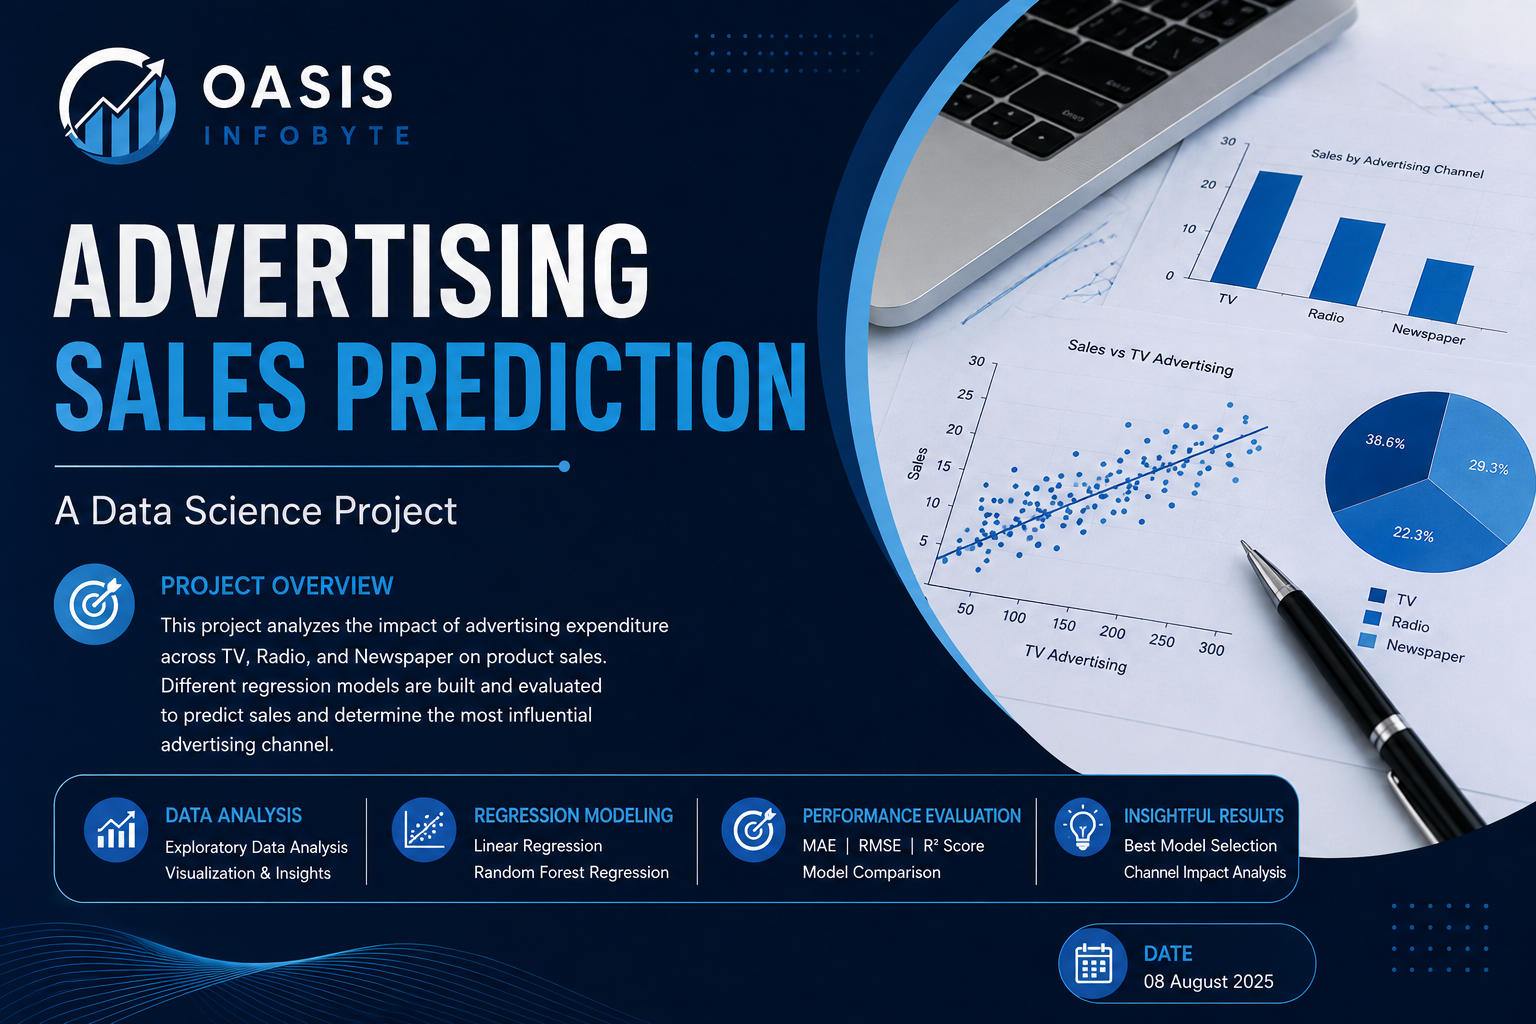

# **Sales Prediction Using Python**

### **Oasis Infobyte Data Science Internship**

> ### **By Somyajeet Satapathy**

> ### **Data Science**

> ### **Task 5 — Sales Prediction Using Python**

## **Project Objective**

The objective of this project is to build a regression model that can predict product sales based on advertising expenditure through different media channels.

The dataset contains advertising spending on TV, Radio and Newspaper along with the corresponding Sales.

In this project, the data will first be explored and visualized. After that, regression models will be trained and evaluated to find the model that gives better predictions.

In [57]:
# Importing the libraries needed for analysis, visualization and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
## Load the Advertising Dataset

# Reading the CSV file into a DataFrame
advertising_data = pd.read_csv('Advertising.csv')

advertising_data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [59]:
# Checking the structure and data types before cleaning
advertising_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [60]:
# The first column is only an old index, so it is not useful for prediction
advertising_data = advertising_data.drop(columns=['Unnamed: 0'])

advertising_data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [61]:
## Checking for Missing Values

advertising_data.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [62]:
## Descriptive Statistics

advertising_data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [63]:
## Checking for Duplicate Records

advertising_data.duplicated().sum()

np.int64(0)

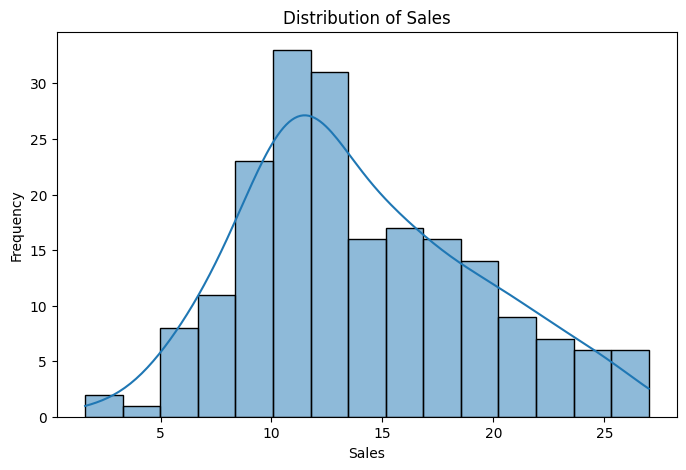

In [64]:
## Distribution of Sales

plt.figure(figsize=(8, 5))
sns.histplot(advertising_data['Sales'], bins=15, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

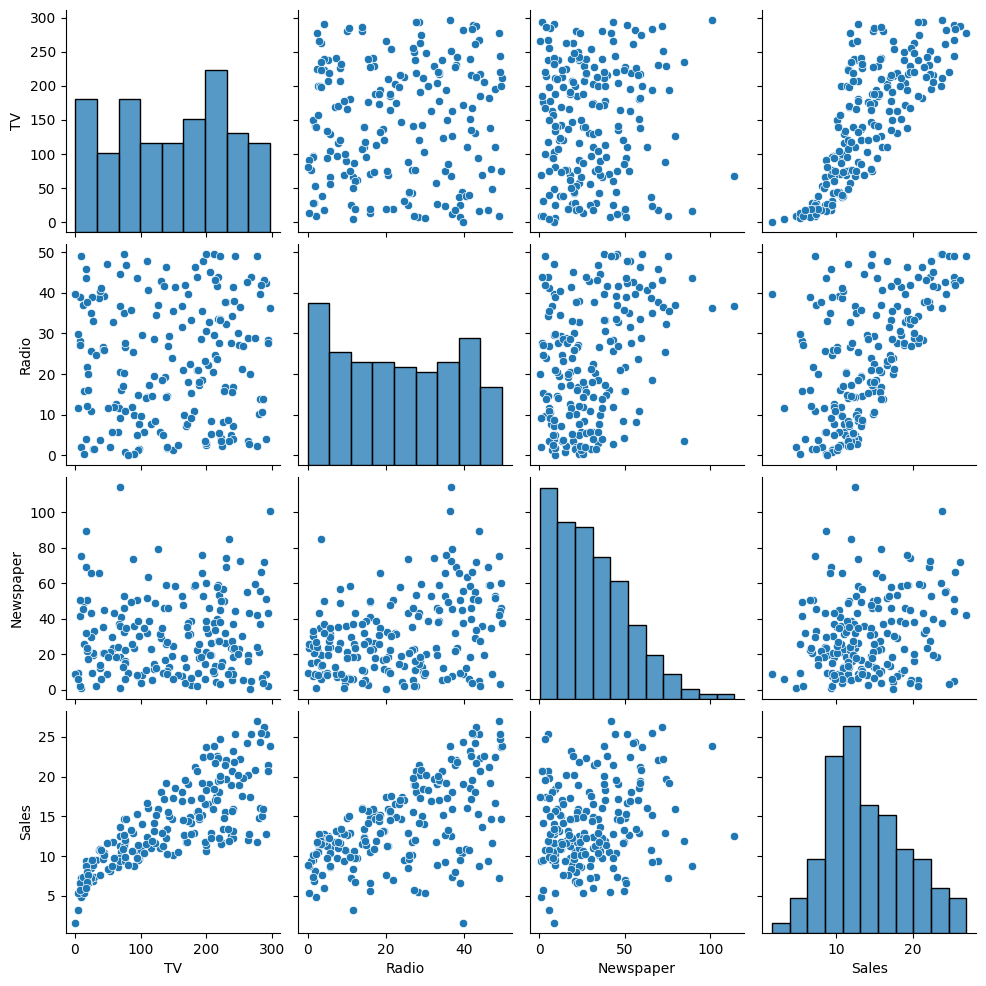

In [65]:
## Pairplot of Advertising Data

sns.pairplot(advertising_data)
plt.show()

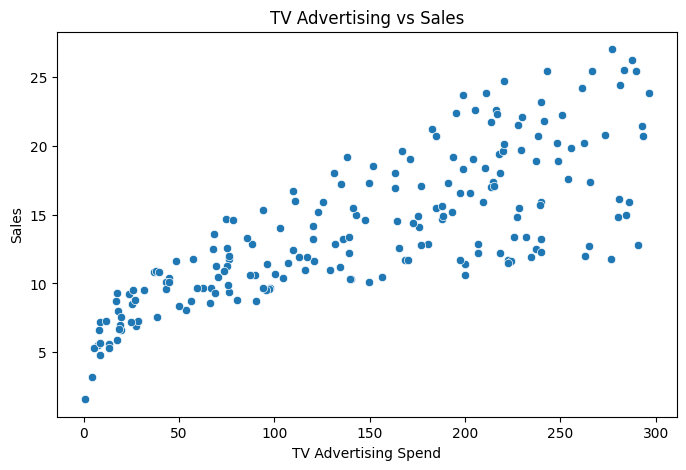

In [66]:
## Relationship Between TV Advertising and Sales

plt.figure(figsize=(8, 5))
sns.scatterplot(data=advertising_data, x='TV', y='Sales')
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.show()

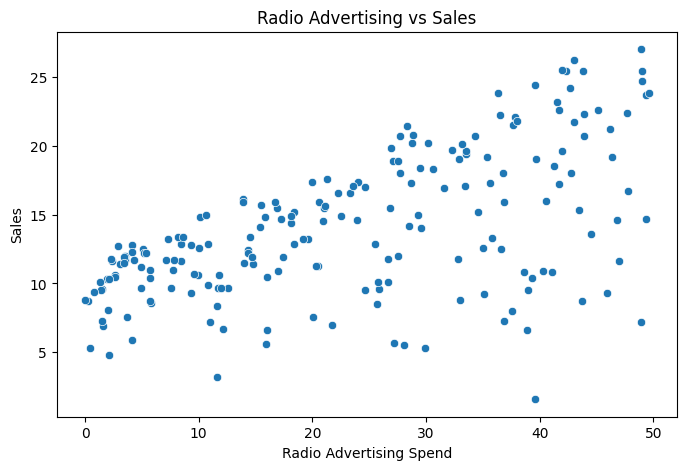

In [67]:
## Relationship Between Radio Advertising and Sales

plt.figure(figsize=(8, 5))
sns.scatterplot(data=advertising_data, x='Radio', y='Sales')
plt.title('Radio Advertising vs Sales')
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.show()

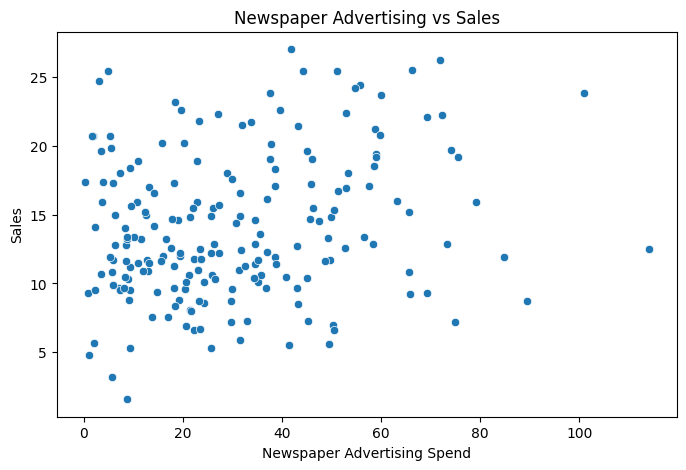

In [68]:
## Relationship Between Newspaper Advertising and Sales

plt.figure(figsize=(8, 5))
sns.scatterplot(data=advertising_data, x='Newspaper', y='Sales')
plt.title('Newspaper Advertising vs Sales')
plt.xlabel('Newspaper Advertising Spend')
plt.ylabel('Sales')
plt.show()

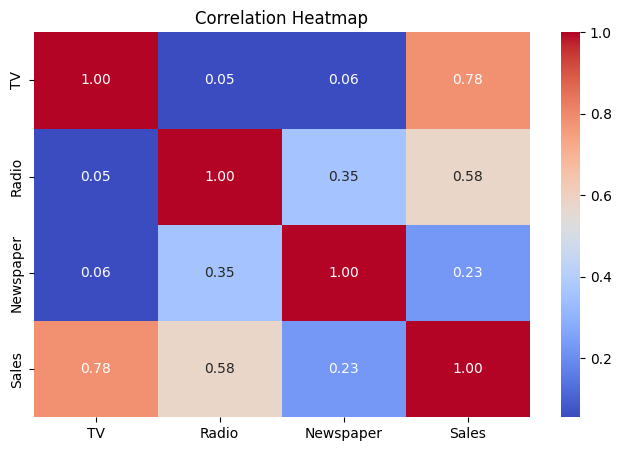

In [69]:
## Correlation Between Advertising Channels and Sales

correlation_table = advertising_data.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_table, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [70]:
## Separating Advertising Features and Sales Target

advertising_features = advertising_data[['TV', 'Radio', 'Newspaper']]
sales_target = advertising_data['Sales']

advertising_features.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [71]:
## Splitting the Data for Training and Testing

from sklearn.model_selection import train_test_split

training_features, testing_features, training_sales, testing_sales = train_test_split(
    advertising_features,
    sales_target,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(training_features))
print("Testing samples:", len(testing_features))

Training samples: 160
Testing samples: 40


In [72]:
## Training the Linear Regression Model

from sklearn.linear_model import LinearRegression

linear_sales_model = LinearRegression()
linear_sales_model.fit(training_features, training_sales)

predicted_sales_linear = linear_sales_model.predict(testing_features)

In [73]:
## Evaluating Linear Regression Performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_mae = mean_absolute_error(testing_sales, predicted_sales_linear)
linear_rmse = np.sqrt(mean_squared_error(testing_sales, predicted_sales_linear))
linear_r2 = r2_score(testing_sales, predicted_sales_linear)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1.4607567168117603
Linear Regression RMSE: 1.78159966153345
Linear Regression R²: 0.899438024100912


In [74]:
## Training the Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

forest_sales_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_sales_model.fit(training_features, training_sales)

predicted_sales_forest = forest_sales_model.predict(testing_features)

In [75]:
## Evaluating Random Forest Performance

forest_mae = mean_absolute_error(testing_sales, predicted_sales_forest)
forest_rmse = np.sqrt(mean_squared_error(testing_sales, predicted_sales_forest))
forest_r2 = r2_score(testing_sales, predicted_sales_forest)

print("Random Forest MAE:", forest_mae)
print("Random Forest RMSE:", forest_rmse)
print("Random Forest R²:", forest_r2)

Random Forest MAE: 0.6200999999999988
Random Forest RMSE: 0.7685910811348248
Random Forest R²: 0.9812843792541843


In [76]:
## Comparing the Regression Models

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regression'],
    'MAE': [linear_mae, forest_mae],
    'RMSE': [linear_rmse, forest_rmse],
    'R²': [linear_r2, forest_r2]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest Regression,0.620100,0.768591,0.981284


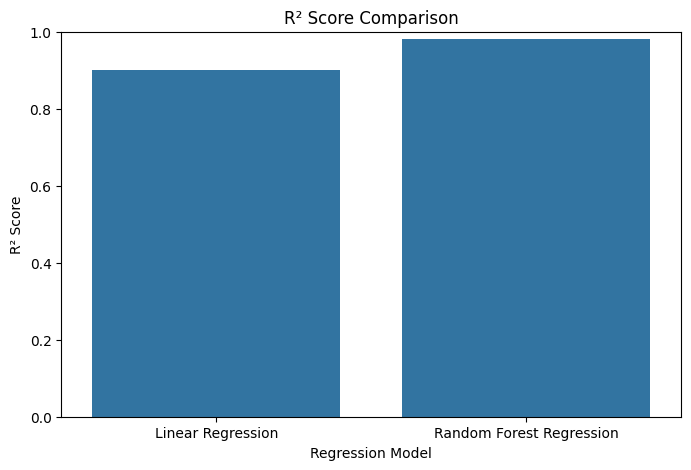

In [77]:
## Comparing Model R² Scores

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x='Model', y='R²')
plt.title('R² Score Comparison')
plt.xlabel('Regression Model')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.show()

In [78]:
## Comparing Actual Sales with Random Forest Predictions

prediction_check = pd.DataFrame({
    'Actual Sales': testing_sales.values,
    'Predicted Sales': predicted_sales_forest
})

prediction_check.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.628
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


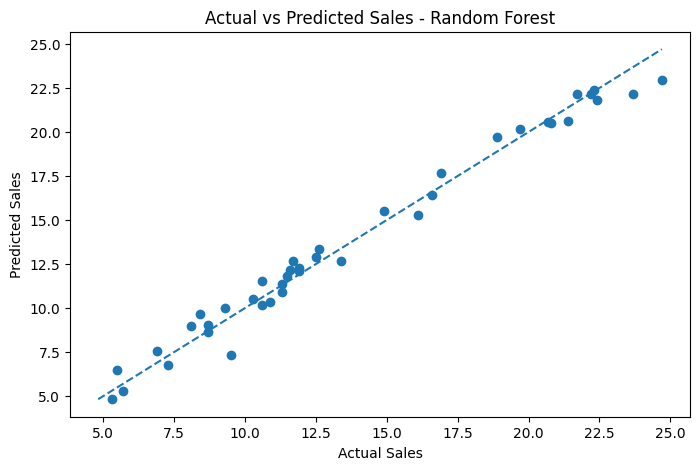

In [79]:
## Actual Sales vs Predicted Sales

plt.figure(figsize=(8, 5))
plt.scatter(testing_sales, predicted_sales_forest)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales - Random Forest')

minimum_sales = min(testing_sales.min(), predicted_sales_forest.min())
maximum_sales = max(testing_sales.max(), predicted_sales_forest.max())

plt.plot([minimum_sales, maximum_sales], [minimum_sales, maximum_sales], linestyle='--')
plt.show()

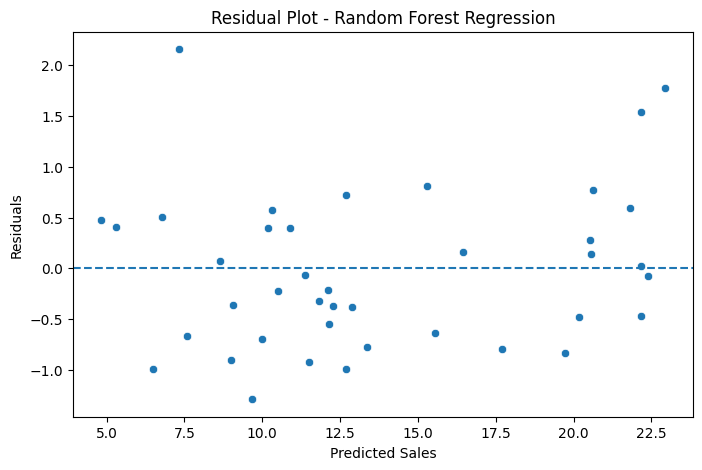

In [80]:
## Residual Analysis for the Best Model

sales_residuals = testing_sales - predicted_sales_forest

plt.figure(figsize=(8, 5))
sns.scatterplot(x=predicted_sales_forest, y=sales_residuals)
plt.axhline(y=0, linestyle='--')
plt.title('Residual Plot - Random Forest Regression')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.show()

In [81]:
## Measuring the Impact of Each Advertising Channel

channel_impact = pd.DataFrame({
    'Advertising Channel': ['TV', 'Radio', 'Newspaper'],
    'Model Coefficient': linear_sales_model.coef_
})

channel_impact

,Advertising Channel,Model Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


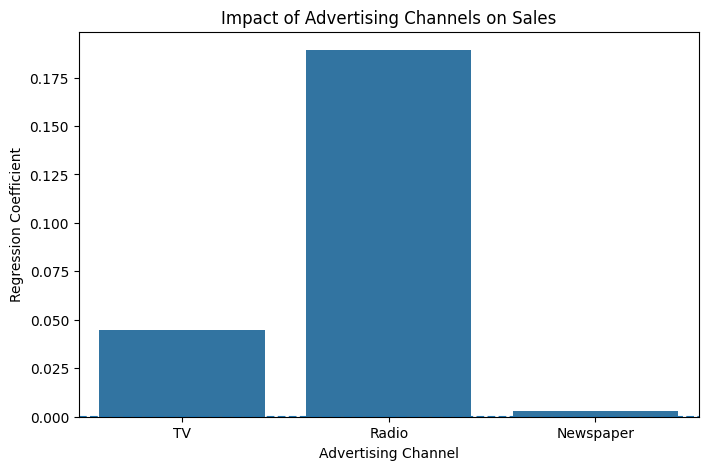

In [82]:
## Advertising Channel Impact on Sales

plt.figure(figsize=(8, 5))
sns.barplot(data=channel_impact, x='Advertising Channel', y='Model Coefficient')
plt.title('Impact of Advertising Channels on Sales')
plt.xlabel('Advertising Channel')
plt.ylabel('Regression Coefficient')
plt.axhline(y=0, linestyle='--')
plt.show()

In [83]:
## Finding the Advertising Channel with the Highest Impact

highest_impact_channel = channel_impact.loc[
    channel_impact['Model Coefficient'].abs().idxmax(),
    'Advertising Channel'
]

highest_impact_value = channel_impact['Model Coefficient'].abs().max()

print("Highest impact advertising channel:", highest_impact_channel)
print("Coefficient magnitude:", highest_impact_value)

Highest impact advertising channel: Radio
Coefficient magnitude: 0.18919505423437652


In [84]:
## Final Model Performance Summary

best_sales_model = 'Random Forest Regression'

print("Best Model:", best_sales_model)
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

Best Model: Random Forest Regression
MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R²: 0.9812843792541843


## Project Conclusion

The advertising data was analyzed to understand how spending across TV, Radio and Newspaper relates to product sales.

Two regression models were trained and compared: Linear Regression and Random Forest Regression.

Linear Regression achieved an R² score of 0.8994, while Random Forest Regression achieved a higher R² score of 0.9813 with lower MAE and RMSE values. Therefore, Random Forest Regression performed better on the test data and was selected as the best model.

The analysis of the Linear Regression coefficients showed that Radio had the highest impact among the three advertising channels, followed by TV and Newspaper.

Overall, the project demonstrates how advertising expenditure can be used to predict sales and how different regression models can be compared using appropriate evaluation metrics.

## Final Results

**Best Model:** Random Forest Regression

**MAE:** 0.6201

**RMSE:** 0.7686

**R² Score:** 0.9813

**Highest Impact Advertising Channel:** Radio

**Radio Coefficient Magnitude:** 0.1892

# **---------------------------------THANK YOU---------------------------------**